In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Project\amazon_sales_cleaned.csv")

In [3]:
df.head()

,order_id,order_date,customer_id,customer_name,product_id,product_name,category,brand,quantity,unit_price,...,tax,shipping_cost,total_amount,payment_method,order_status,city,state,country,seller_id,new_order_date
0,88937,05-05-2021,42927,Aman Kapoor,10,Smartwatch,Books,HomeEase,1,392.16,...,31.37,11.25,434.78,UPI,Delivered,Columbus,OH,Canada,428,2021-05-05
1,82558,12-05-2024,14390,Aman Sharma,21,Backpack,Books,Zenith,5,275.32,...,0.00,9.75,1111.03,Amazon Pay,Delivered,Dallas,TX,Canada,943,2024-05-12
2,22043,28-11-2022,11788,Anjali Reddy,36,Smart Light Bulb,Clothing,CoreTech,1,549.26,...,65.91,1.59,616.76,Credit Card,Delivered,Denver,CO,India,128,2022-11-28
3,35180,20-07-2024,14674,Anjali Reddy,24,Yoga Mat,Books,BrightLux,1,308.03,...,0.00,3.68,234.70,Debit Card,Delivered,San Francisco,CA,India,209,2024-07-20
4,26274,26-05-2022,36939,Anjali Verma,16,Air Fryer,Books,BrightLux,5,406.47,...,0.00,3.68,2036.03,Credit Card,Delivered,San Jose,CA,United States,144,2022-05-26


In [4]:
print(df.columns)

Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'product_id',
       'product_name', 'category', 'brand', 'quantity', 'unit_price',
       'discount', 'tax', 'shipping_cost', 'total_amount', 'payment_method',
       'order_status', 'city', 'state', 'country', 'seller_id',
       'new_order_date'],
      dtype='object')


In [5]:
df.dtypes

order_id            int64
order_date         object
customer_id         int64
customer_name      object
product_id          int64
product_name       object
category           object
brand              object
quantity            int64
unit_price        float64
discount          float64
tax               float64
shipping_cost     float64
total_amount      float64
payment_method     object
order_status       object
city               object
state              object
country            object
seller_id           int64
new_order_date     object
dtype: object

In [6]:

df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%d-%m-%Y'
)

In [7]:
print(df['order_date'].head())

0   2021-05-05
1   2024-05-12
2   2022-11-28
3   2024-07-20
4   2022-05-26
Name: order_date, dtype: datetime64[ns]


In [8]:
df['Month'] = df['order_date'].dt.month_name()

# Create Revenue Column

In [9]:
df["Revenue"] = (
    (df["quantity"] * df["unit_price"])
    - df["discount"]
)


# Create Estimated Cost Column

In [10]:
df["Estimated_Cost"] = (
    df["quantity"] * df["unit_price"]
) * 0.70

# Create Profit Column

In [11]:
df["Profit"] = (
    df["Revenue"]
    - (
        df["Estimated_Cost"]
        + df["shipping_cost"]
        + df["tax"]
    )
)

In [12]:
df.head()

,order_id,order_date,customer_id,customer_name,product_id,product_name,category,brand,quantity,unit_price,...,order_status,city,state,country,seller_id,new_order_date,Month,Revenue,Estimated_Cost,Profit
0,88937,2021-05-05,42927,Aman Kapoor,10,Smartwatch,Books,HomeEase,1,392.16,...,Delivered,Columbus,OH,Canada,428,2021-05-05,May,392.16,274.512,75.028
1,82558,2024-05-12,14390,Aman Sharma,21,Backpack,Books,Zenith,5,275.32,...,Delivered,Dallas,TX,Canada,943,2024-05-12,May,1376.40,963.620,403.030
2,22043,2022-11-28,11788,Anjali Reddy,36,Smart Light Bulb,Clothing,CoreTech,1,549.26,...,Delivered,Denver,CO,India,128,2022-11-28,November,549.26,384.482,97.278
3,35180,2024-07-20,14674,Anjali Reddy,24,Yoga Mat,Books,BrightLux,1,308.03,...,Delivered,San Francisco,CA,India,209,2024-07-20,July,307.78,215.621,88.479
4,26274,2022-05-26,36939,Anjali Verma,16,Air Fryer,Books,BrightLux,5,406.47,...,Delivered,San Jose,CA,United States,144,2022-05-26,May,2032.35,1422.645,606.025


In [13]:
# Total Sales
total_sales = df['total_amount'].sum()
print(total_sales)

91825647.92


In [14]:
# Average Order Value
avg_order = df['total_amount'].mean()
print(avg_order)

918.2564792000001


# TOTAL REVENUE


In [15]:
total_revenue = df['Revenue'].sum()
print("\nTOTAL REVENUE :", total_revenue)


TOTAL REVENUE : 91013790.38999999


# TOTAL PROFIT

In [16]:
total_profit = df['Profit'].sum()
print("TOTAL PROFIT :", total_profit)

TOTAL PROFIT : 19711385.127


# TOP SELLING PRODUCTS

In [17]:
top_products = (
    df.groupby('product_name')['quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP SELLING PRODUCTS")
print(top_products)


TOP SELLING PRODUCTS
product_name
LED Desk Lamp          6344
Water Bottle           6275
Memory Card 128GB      6240
Router                 6202
Board Game             6200
Microphone             6196
Gaming Mouse           6170
Electric Kettle        6165
Mechanical Keyboard    6161
Vacuum Cleaner         6139
Name: quantity, dtype: int64


# STATE WISE SALES

In [18]:

state_sales = (
    df.groupby('state')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 STATES BY SALES")
print(state_sales)


TOP 10 STATES BY SALES
state
TX    22666813.20
CA    18045225.56
NC     4700837.34
WA     4627326.60
PA     4610044.04
IL     4598285.34
CO     4587794.59
IN     4568632.47
FL     4567789.35
OH     4550223.98
Name: Revenue, dtype: float64


# MONTHLY SALES TREND

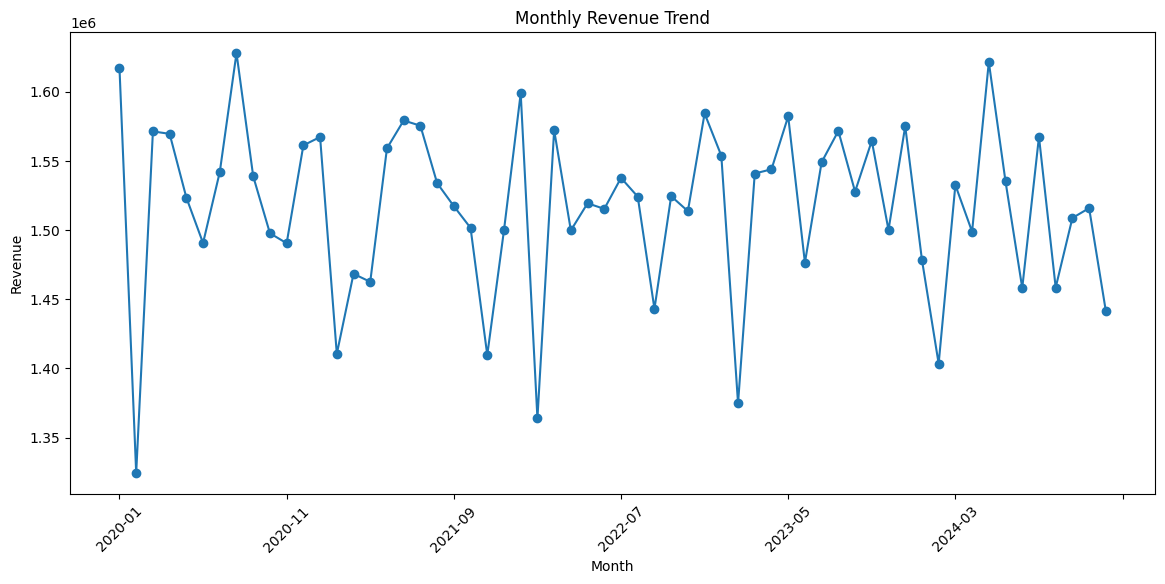

In [19]:

monthly_trend = (
    df.groupby(df['order_date'].dt.to_period('M'))['Revenue']
    .sum()
)

monthly_trend.index = monthly_trend.index.astype(str)

plt.figure(figsize=(14,6))
monthly_trend.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


# Order Status Quantity by Brand

<Figure size 1400x700 with 0 Axes>

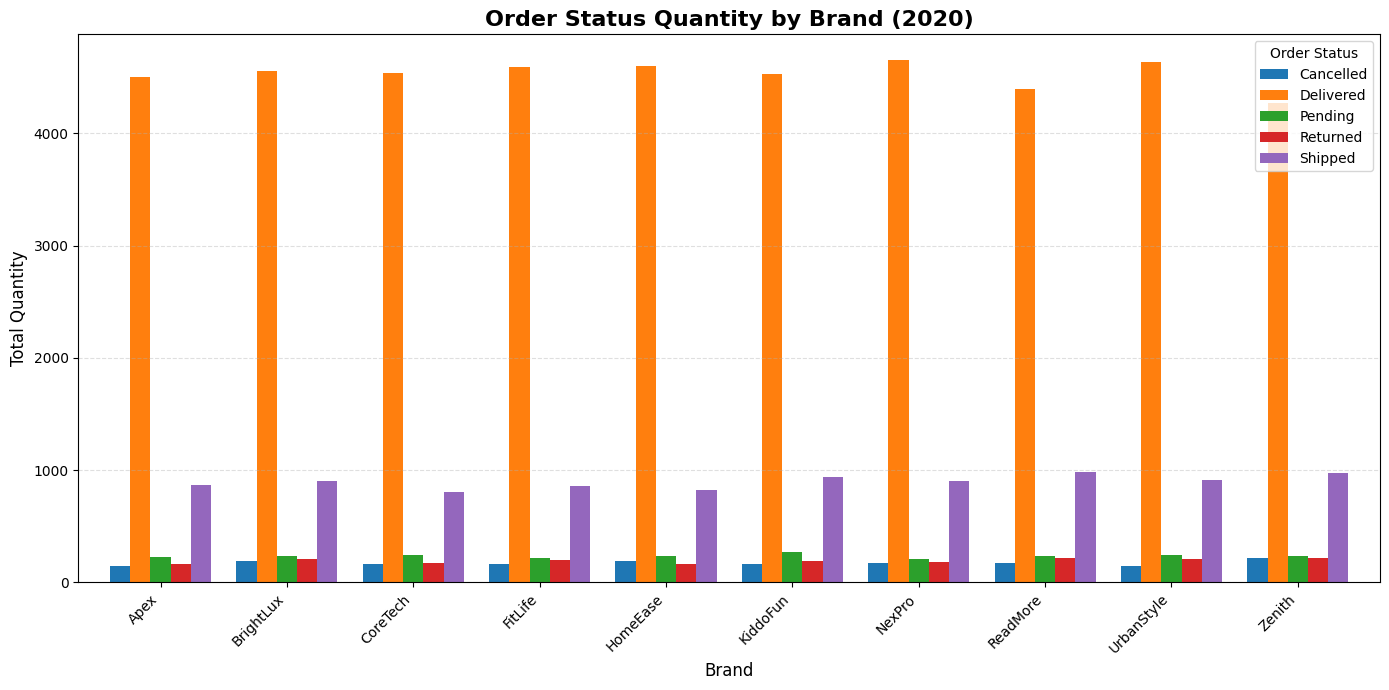

<Figure size 1400x700 with 0 Axes>

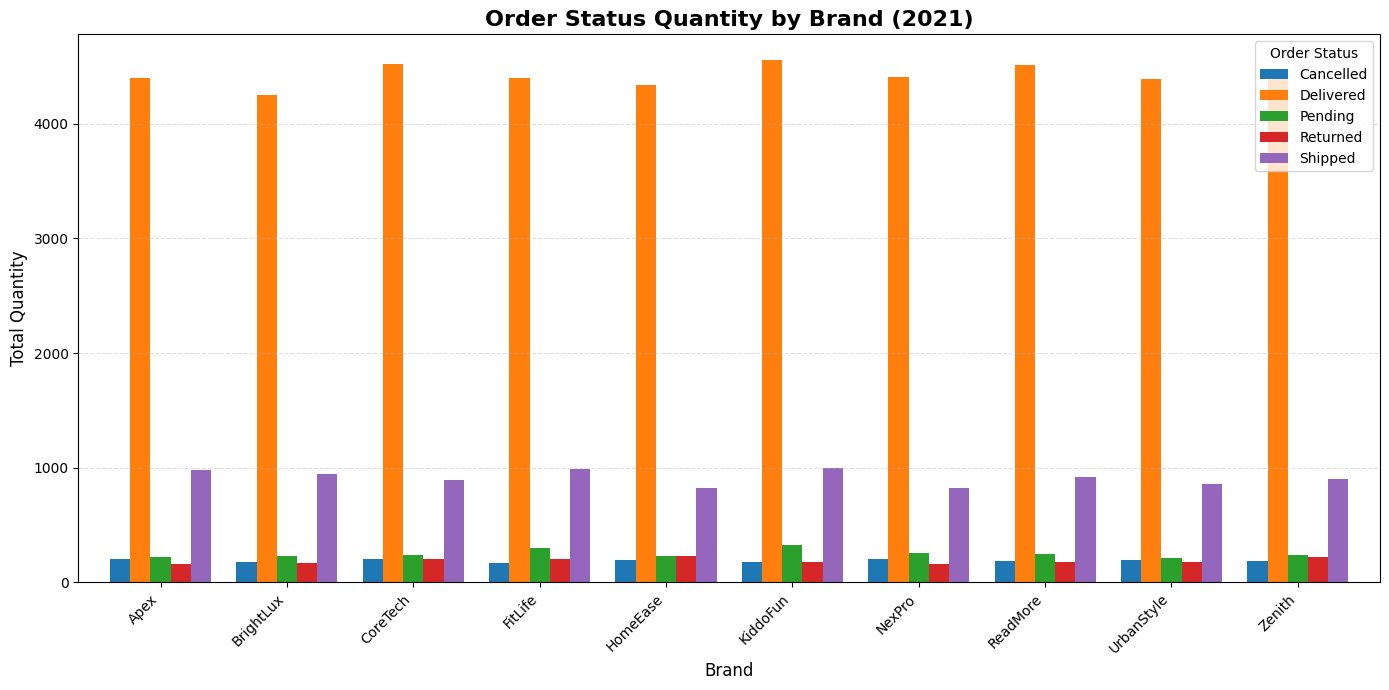

<Figure size 1400x700 with 0 Axes>

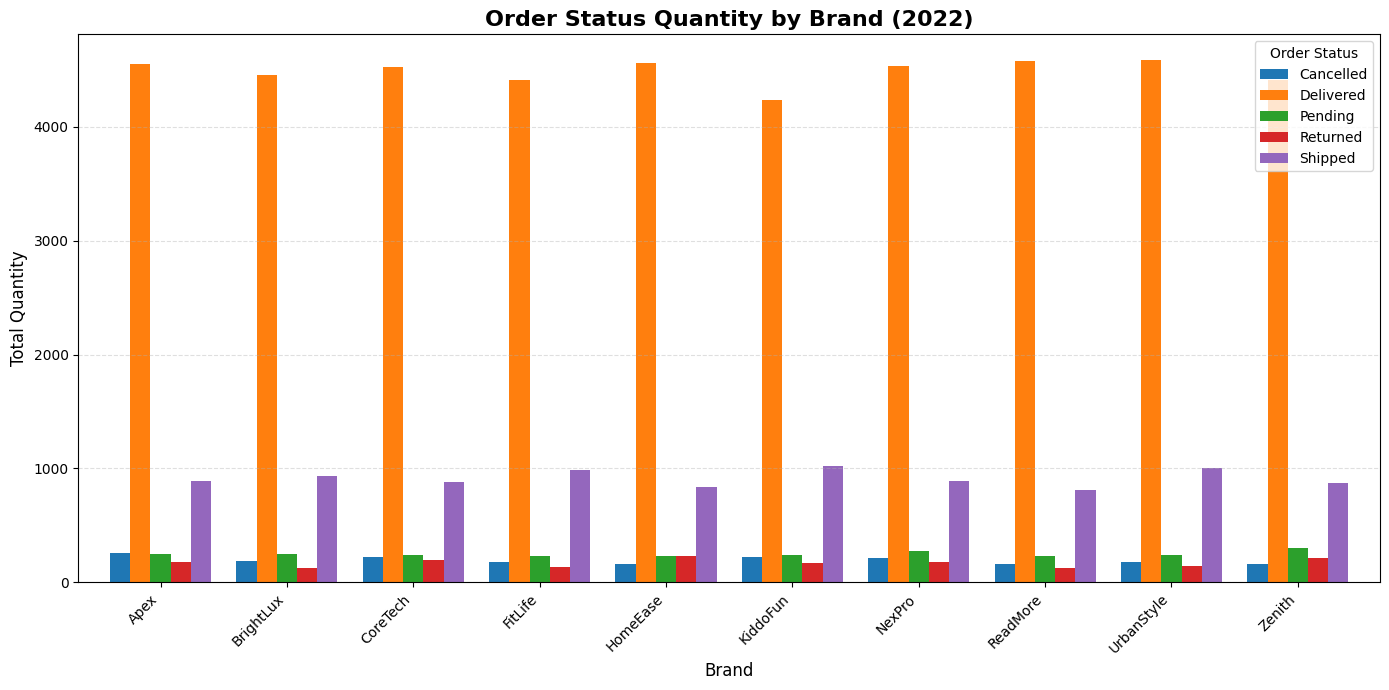

<Figure size 1400x700 with 0 Axes>

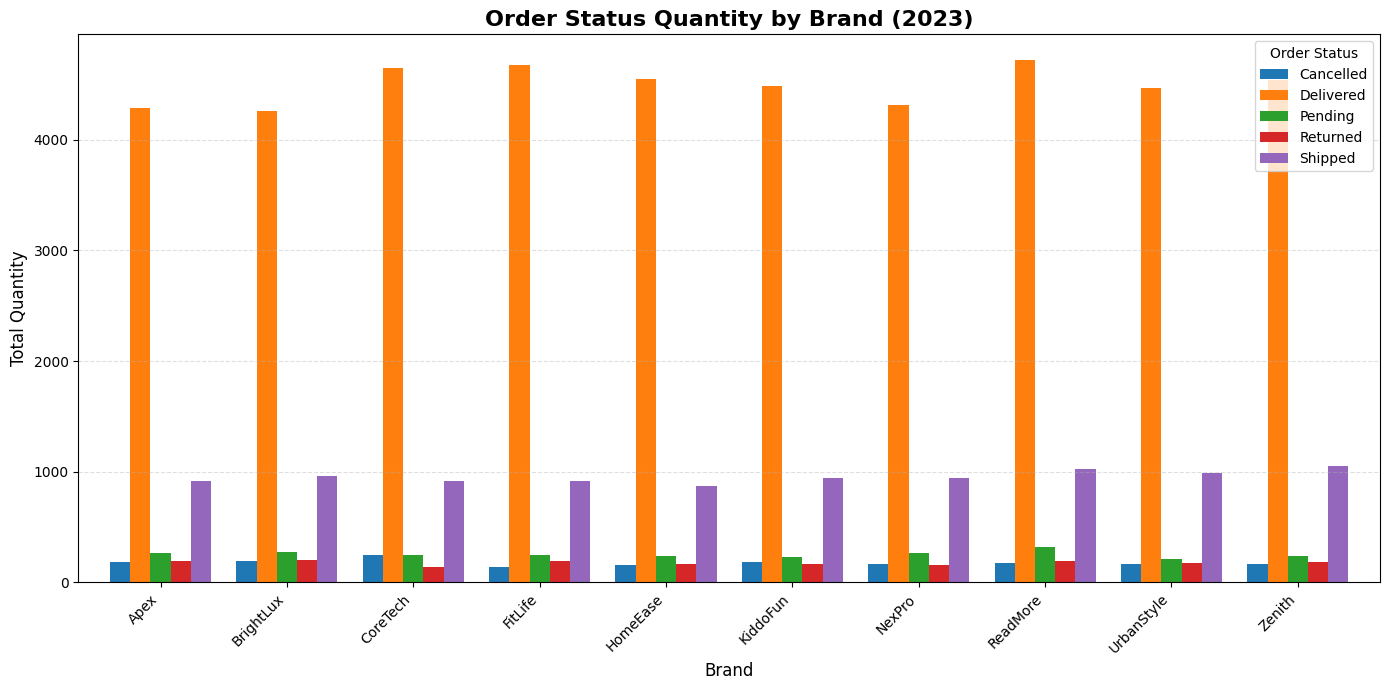

<Figure size 1400x700 with 0 Axes>

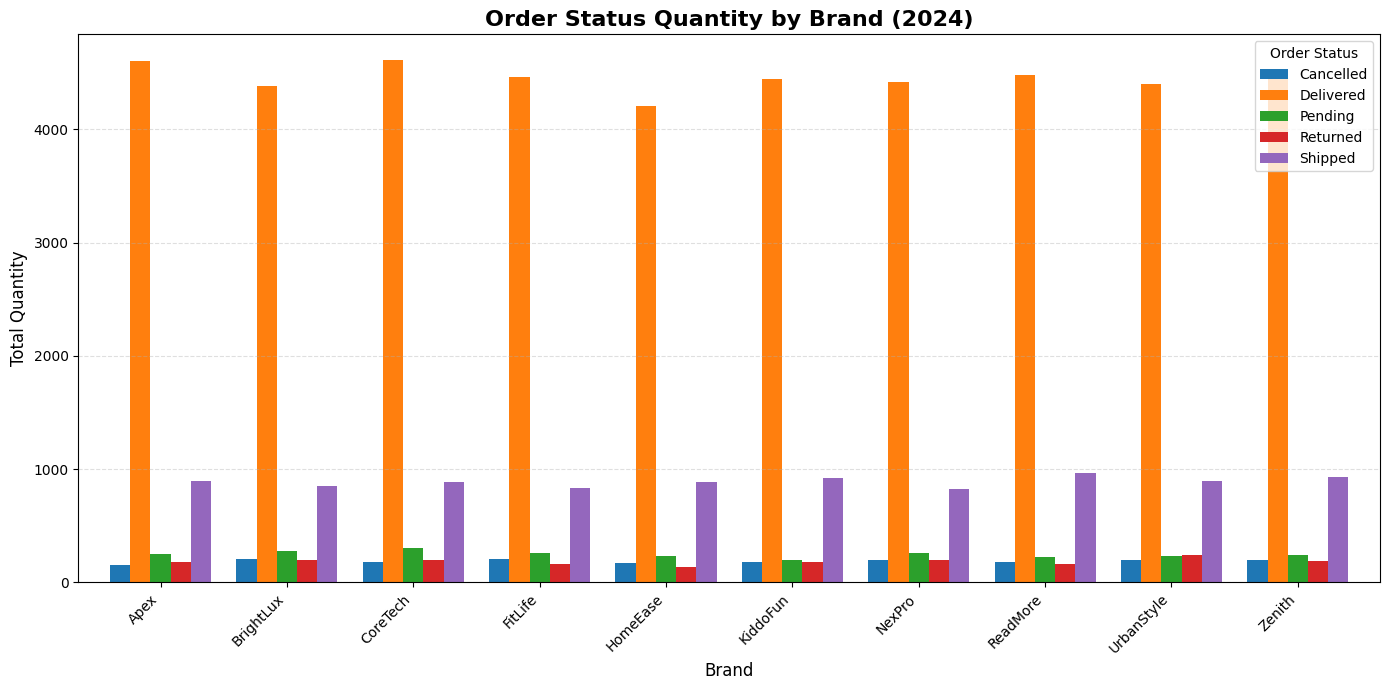

In [20]:


# Convert date column
df["new_order_date"] = pd.to_datetime(df["new_order_date"])

# Create Year column
df["Year"] = df["new_order_date"].dt.year

# Years to plot
years = [2020, 2021, 2022, 2023, 2024]

for year in years:

    # Filter data for the selected year
    year_df = df[df["Year"] == year]

    # Sum Quantity by Brand and Order Status
    chart_data = (
        year_df
        .groupby(["brand", "order_status"])["quantity"]
        .sum()
        .unstack(fill_value=0)
    )

    # Create figure
    plt.figure(figsize=(14, 7))

    # Grouped bar chart
    chart_data.plot(
        kind="bar",
        figsize=(14,7),
        width=0.8
    )

    # Formatting
    plt.title(f"Order Status Quantity by Brand ({year})",
              fontsize=16,
              fontweight="bold")

    plt.xlabel("Brand", fontsize=12)
    plt.ylabel("Total Quantity", fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Order Status")
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

# TOP 10 PRODUCTS

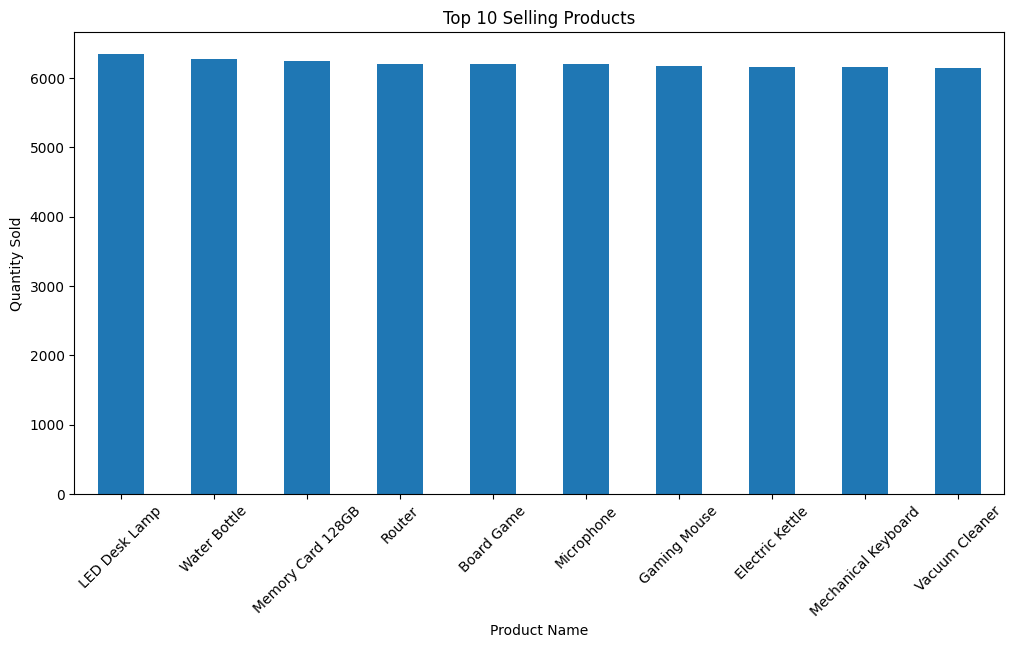

In [21]:

plt.figure(figsize=(12,6))
top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xlabel("Product Name")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

# Shipping Cost Distribution by Category

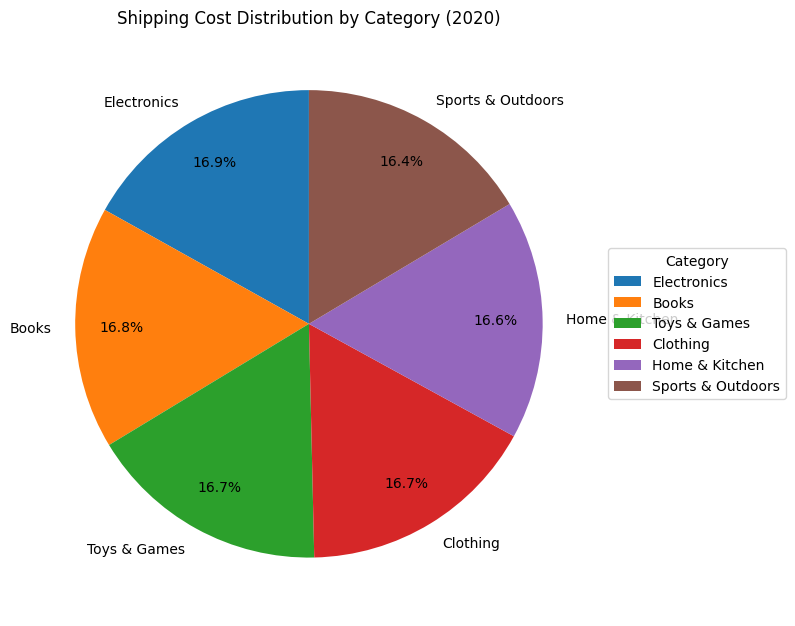

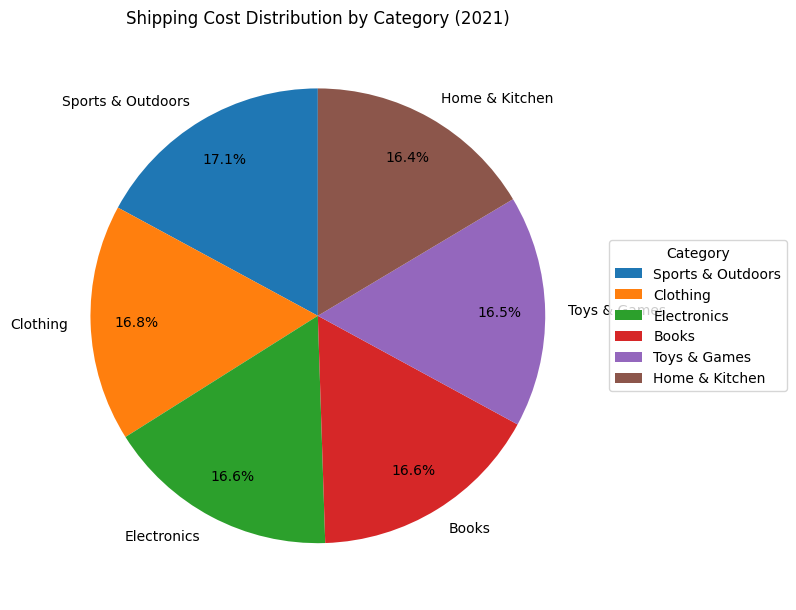

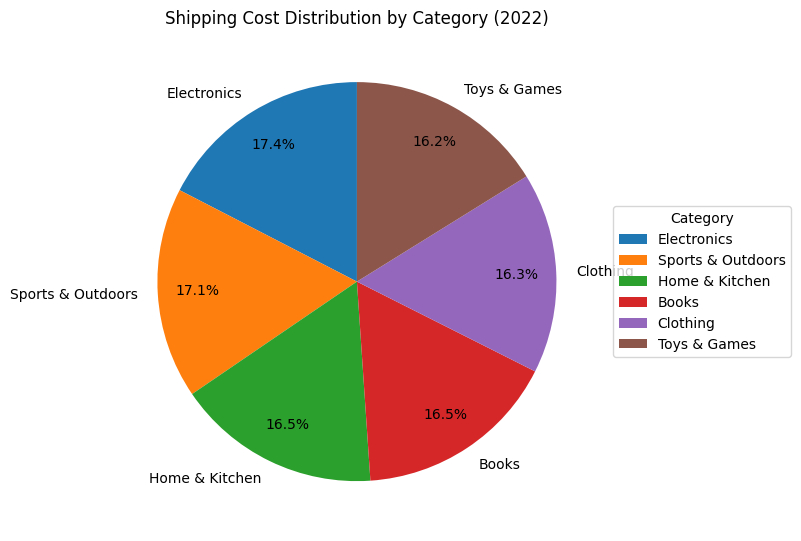

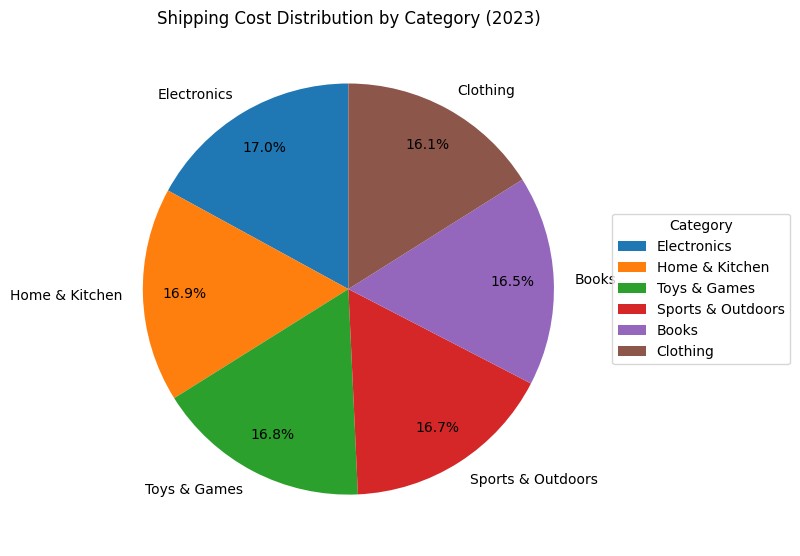

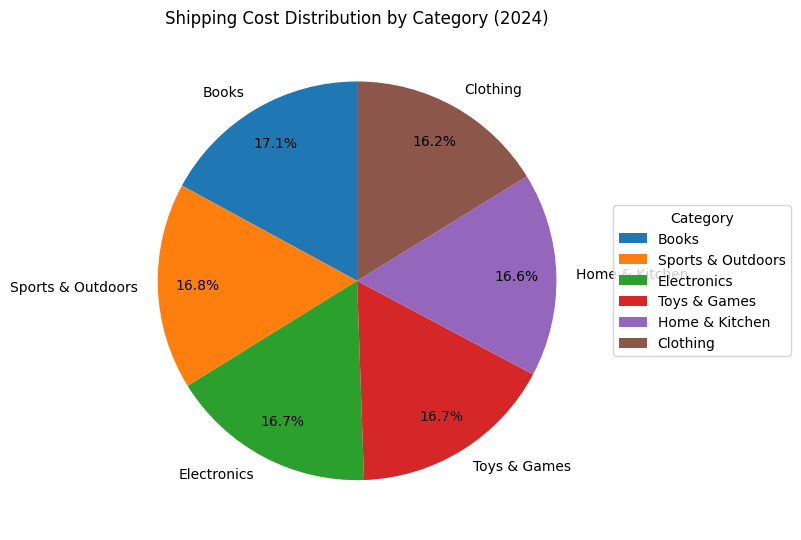

In [22]:
# Pie Charts:
# Category vs Shipping Cost
# Separate chart for each year (2020–2024)
years = [2020, 2021, 2022, 2023, 2024]

for year in years:
    year_data = df[df["Year"] == year]

    if year_data.empty:
        print(f"No data available for {year}")
        continue

    shipping = (
        year_data.groupby("category")["shipping_cost"]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 8))

    plt.pie(
        shipping,
        labels=shipping.index,          # Category labels
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.8
    )

    plt.title(f"Shipping Cost Distribution by Category ({year})")
    plt.legend(
        shipping.index,
        title="Category",
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )

    plt.tight_layout()
    plt.show()

# Category-wise Tax

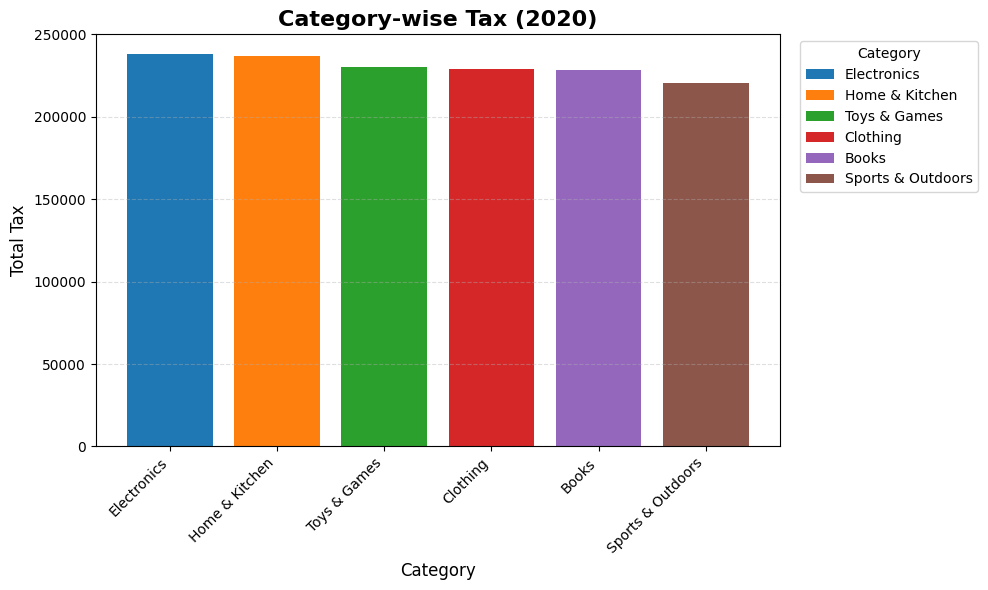

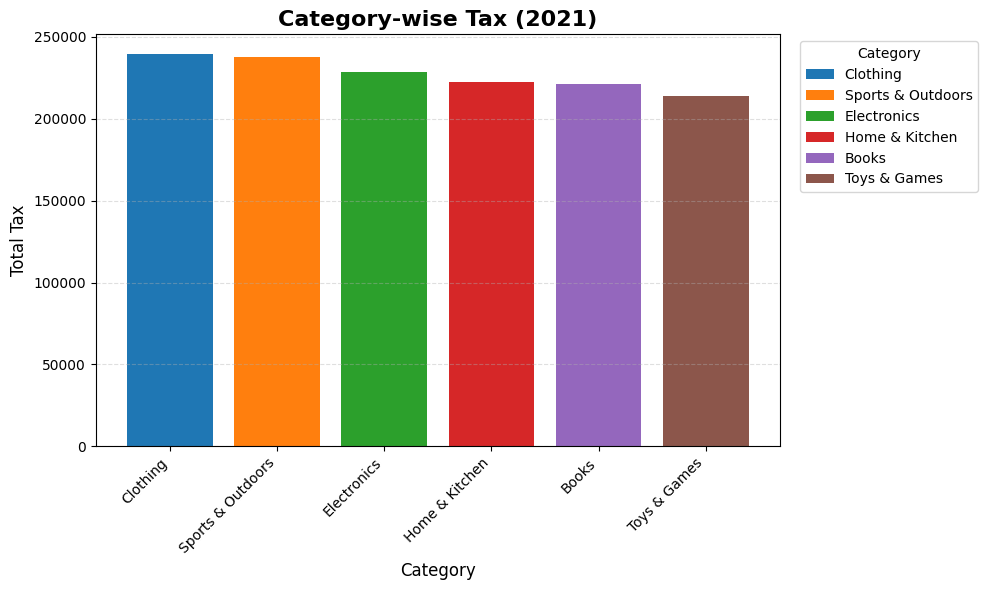

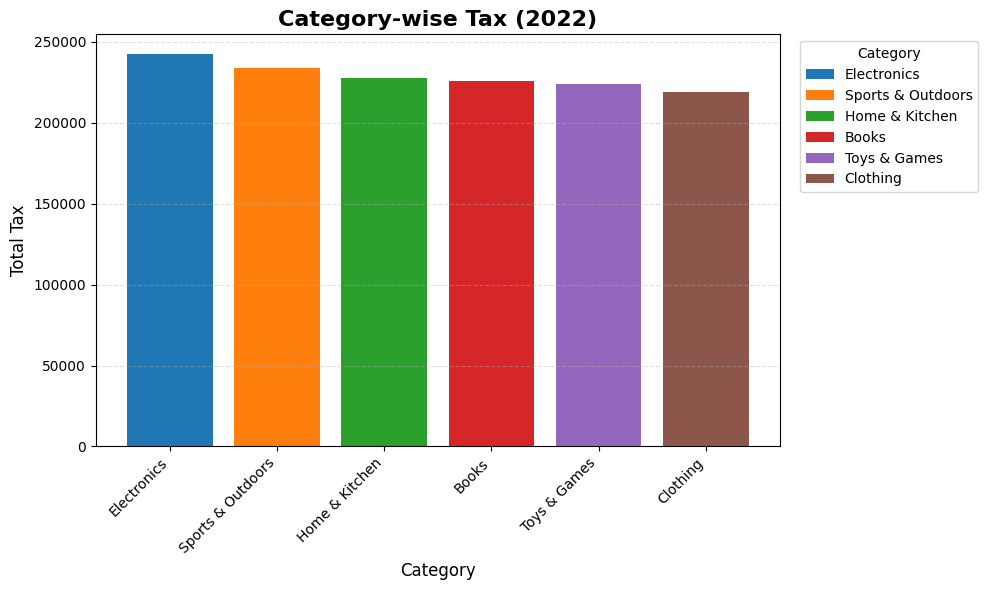

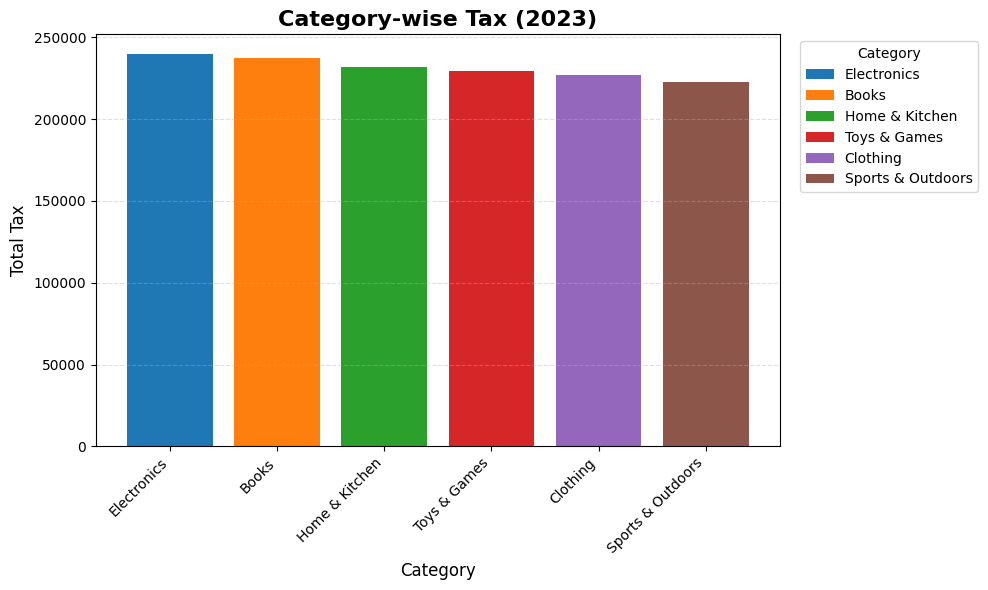

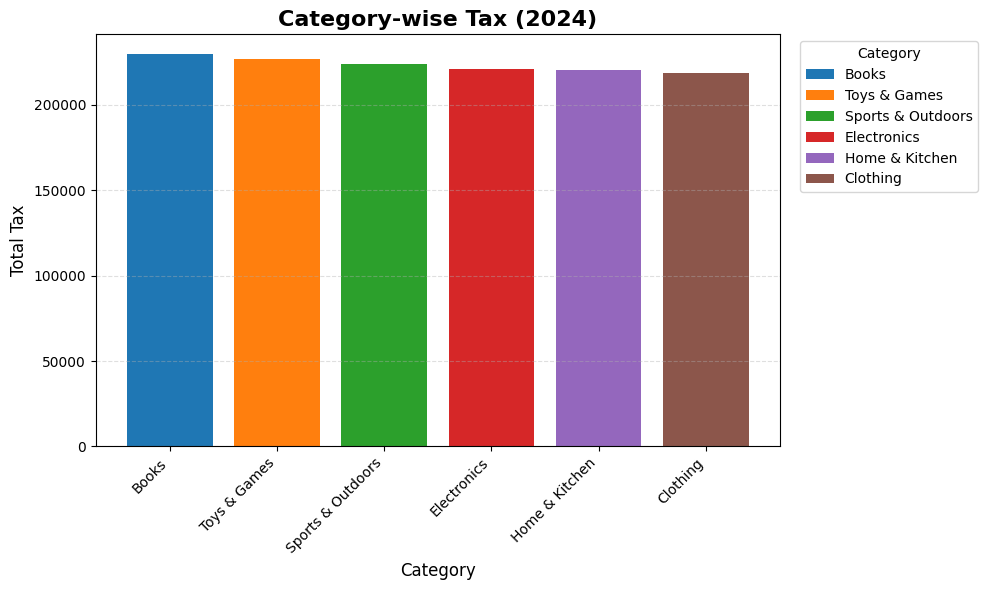

In [23]:

# Convert date column to datetime
df["new_order_date"] = pd.to_datetime(df["new_order_date"])

# Extract Year
df["Year"] = df["new_order_date"].dt.year

# Years to plot
years = [2020, 2021, 2022, 2023, 2024]

for year in years:
    # Filter data for the year
    yearly_data = df[df["Year"] == year]

    # Sum tax by category
    tax_by_category = (
        yearly_data.groupby("category")["tax"]
        .sum()
        .sort_values(ascending=False)
    )

    # Create figure
    plt.figure(figsize=(10, 6))

    # Plot each bar separately so each appears in legend
    for category, tax in tax_by_category.items():
        plt.bar(category, tax, label=category)

    plt.title(f"Category-wise Tax ({year})", fontsize=16, fontweight="bold")
    plt.xlabel("Category", fontsize=12)
    plt.ylabel("Total Tax", fontsize=12)

    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

# Brand-wise Revenue and Profit

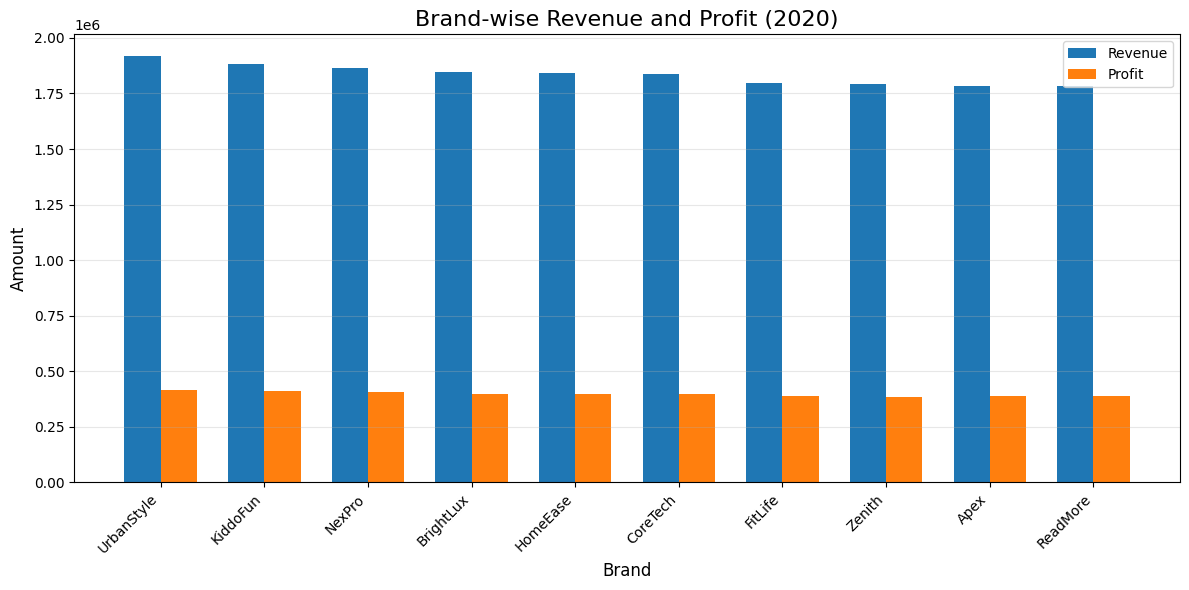

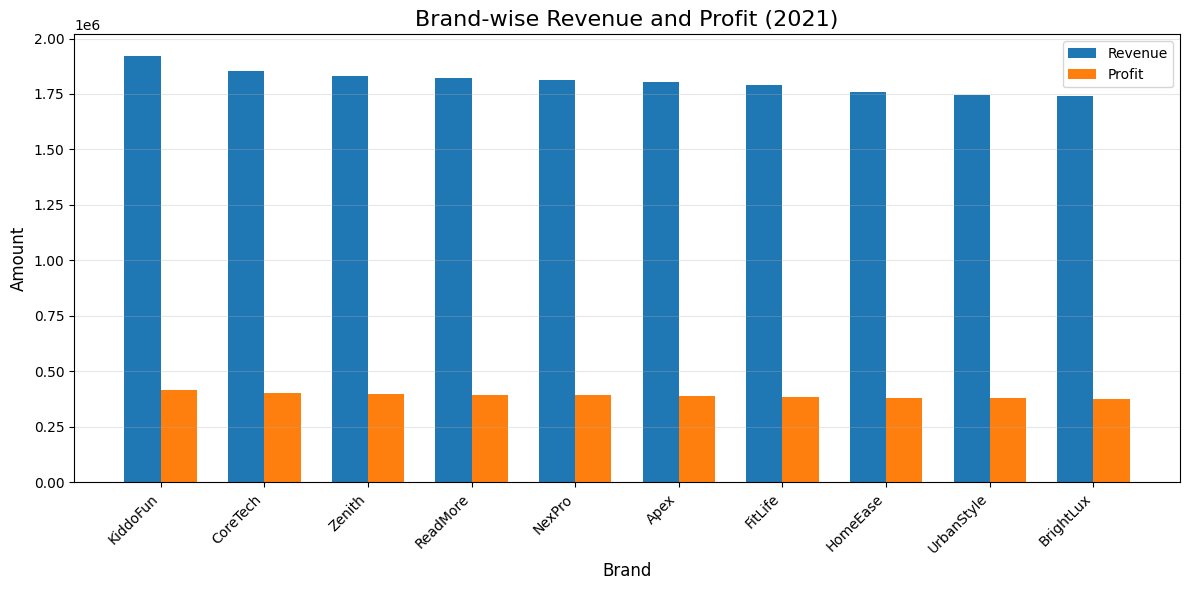

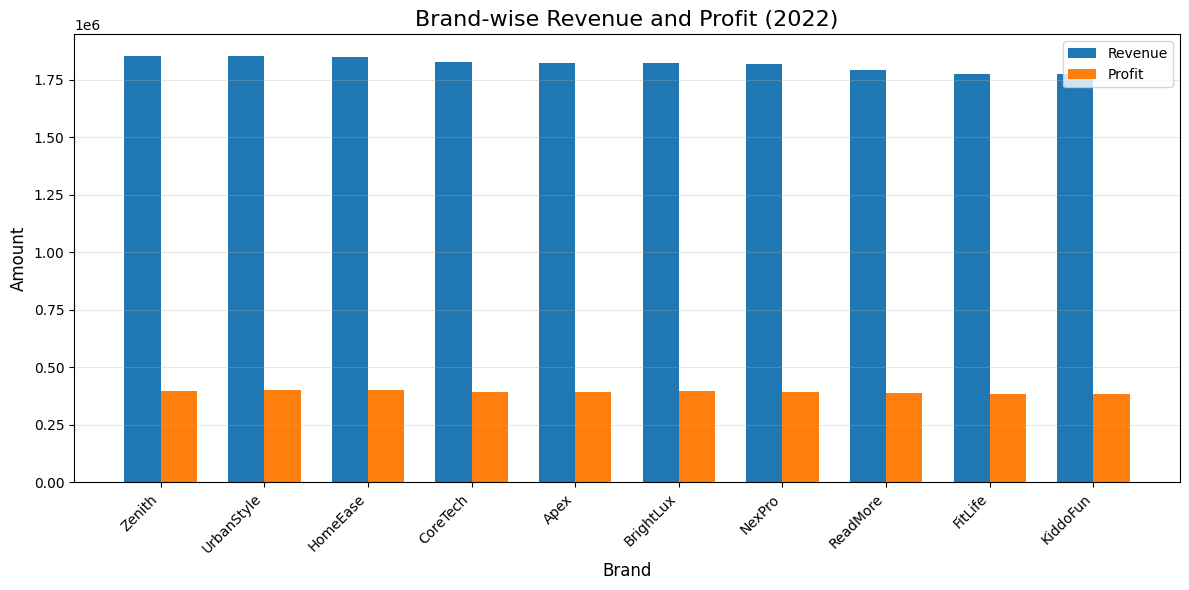

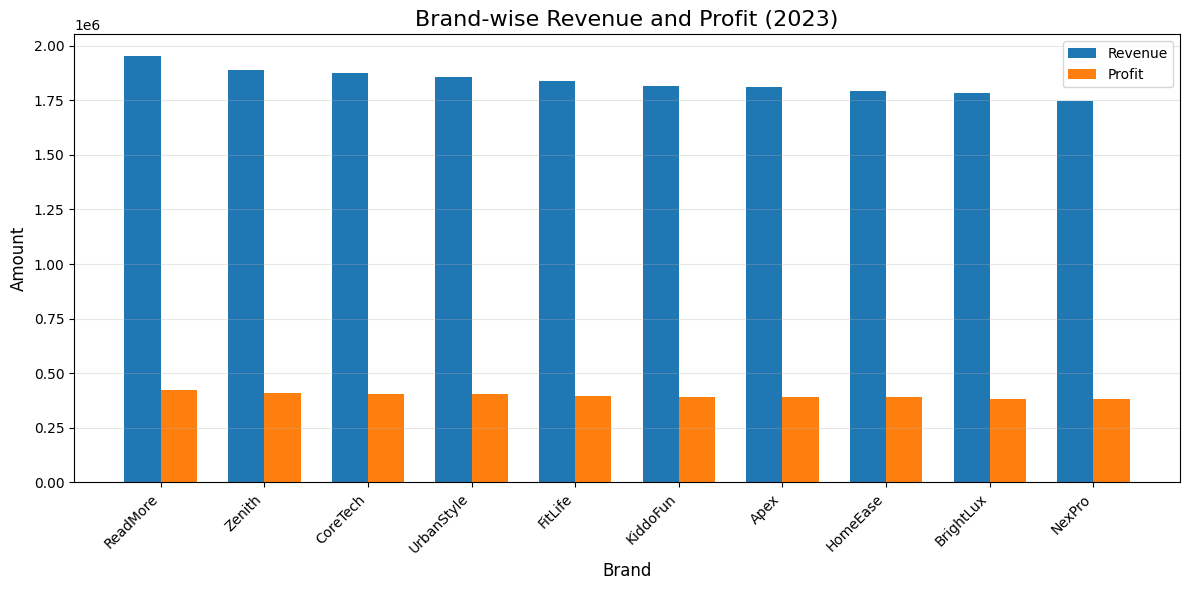

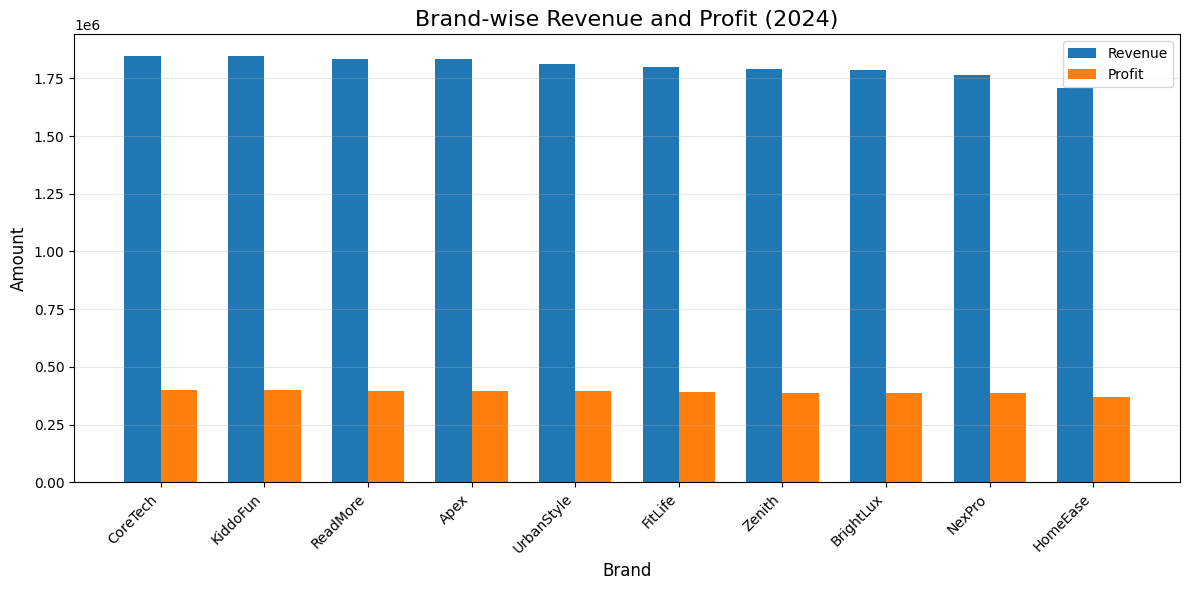

In [24]:

# Convert date to datetime
df["new_order_date"] = pd.to_datetime(df["new_order_date"])

# Extract year
df["Year"] = df["new_order_date"].dt.year
    
# Years to plot
years = [2020, 2021, 2022, 2023, 2024]

for year in years:
    # Filter data
    yearly_df = df[df["Year"] == year]

    # Aggregate Revenue and Profit by Brand
    brand_summary = (
        yearly_df.groupby("brand")[["Revenue", "Profit"]]
        .sum()
        .sort_values("Revenue", ascending=False)
    )
    # Skip if no data
    if brand_summary.empty:
        continue

    x = np.arange(len(brand_summary))
    width = 0.35

    plt.figure(figsize=(12, 6))
    plt.bar(
        x - width/2,
        brand_summary["Revenue"],
        width,
        label="Revenue"
    )
    plt.bar(
        x + width/2,
        brand_summary["Profit"],
        width,
        label="Profit"
    )

    plt.title(f"Brand-wise Revenue and Profit ({year})", fontsize=16)
    plt.xlabel("Brand", fontsize=12)
    plt.ylabel("Amount", fontsize=12)
    plt.xticks(x, brand_summary.index, rotation=45, ha="right")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Category Sales Distribution

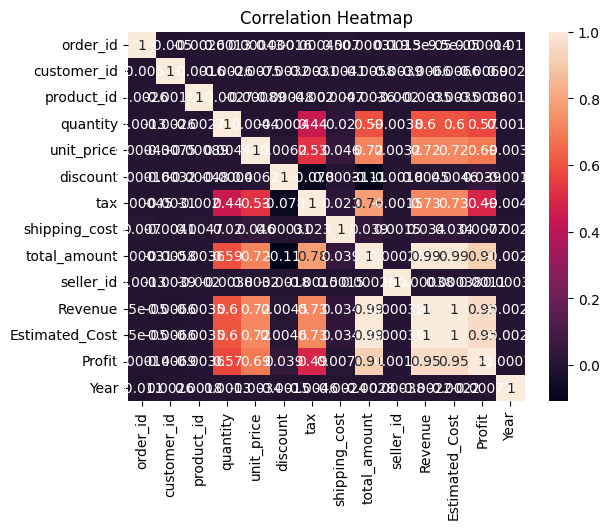

In [25]:
numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
df.to_csv("D:\Project\Amazon_sales_Data_analysis_Project.csv", index=False)